In [1]:
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

from src.config import BEST_MODEL_PATH, LOGS_DIR, NUM_CLASSES, get_actor_splits
from src.dataset import get_dataloaders, load_features_and_labels
from src.model import EmotionCNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


1. Load Data (Test Set) and Confirm Split

In [2]:
train_loader, val_loader, test_loader, label_encoder = get_dataloaders(batch_size=32)

class_names = list(label_encoder.classes_)
print("Classes:", class_names)
print("Test batches:", len(test_loader), "| Test samples:", len(test_loader.dataset))

Train actors (15): [1, 2, 3, 4, 6, 7, 9, 12, 13, 17, 18, 19, 20, 21, 24]
Val actors   (4): [8, 11, 15, 22]
Test actors  (5): [5, 10, 14, 16, 23]
Augmented samples — train: 4500, val: 0 (must be 0), test: 0 (must be 0)
Train samples: 5400 | Val samples: 240 | Test samples: 300
Classes (8): ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Test batches: 10 | Test samples: 300


2. Load Trained Model from Checkpoint

Loads architecture + saved weights together. model.eval() is required — without it, and without loading weights at all, you get random-output predictions (all probability mass on one arbitrary class).

In [3]:
model = EmotionCNN(num_classes=NUM_CLASSES).to(device)

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']} (val_acc={checkpoint['val_acc']:.4f})")

# Sanity check: class order in checkpoint must match current label_encoder
assert checkpoint["label_classes"] == class_names, (
    f"Class order mismatch! checkpoint={checkpoint['label_classes']} "
    f"vs current={class_names}"
)
print("Class order verified OK.")

Loaded checkpoint from epoch 14 (val_acc=0.5542)
Class order verified OK.


3. Load Training History (No Retraining Needed)

In [4]:
history_path = os.path.join(LOGS_DIR, "training_history.csv")
history_df = pd.read_csv(history_path)

peak_row = history_df.loc[history_df["val_acc"].idxmax()]
print(f"History peak: epoch {int(peak_row['epoch'])}, val_acc={peak_row['val_acc']:.4f}")
print(f"Checkpoint says: epoch {checkpoint['epoch']}, val_acc={checkpoint['val_acc']:.4f}")
if int(peak_row["epoch"]) != checkpoint["epoch"]:
    print("WARNING: history_df does not match the loaded checkpoint — "
          "likely from a different (later) training run.")

history_df.tail(10)

History peak: epoch 14, val_acc=0.5542
Checkpoint says: epoch 14, val_acc=0.5542


,epoch,train_loss,train_acc,val_loss,val_acc,lr
12,13,0.820374,0.696296,2.010057,0.350000,0.000500
13,14,0.780494,0.713333,1.220184,0.554167,0.000500
14,15,0.734676,0.731852,1.363458,0.512500,0.000500
15,16,0.697781,0.745556,1.868321,0.441667,0.000500
16,17,0.643547,0.764074,1.766803,0.475000,0.000500
17,18,0.631730,0.772222,2.441355,0.325000,0.000250
18,19,0.555156,0.803704,1.270453,0.545833,0.000250
19,20,0.542439,0.801481,1.429340,0.550000,0.000250
20,21,0.520757,0.808704,1.824271,0.466667,0.000250
21,22,0.504944,0.818519,1.701758,0.483333,0.000125


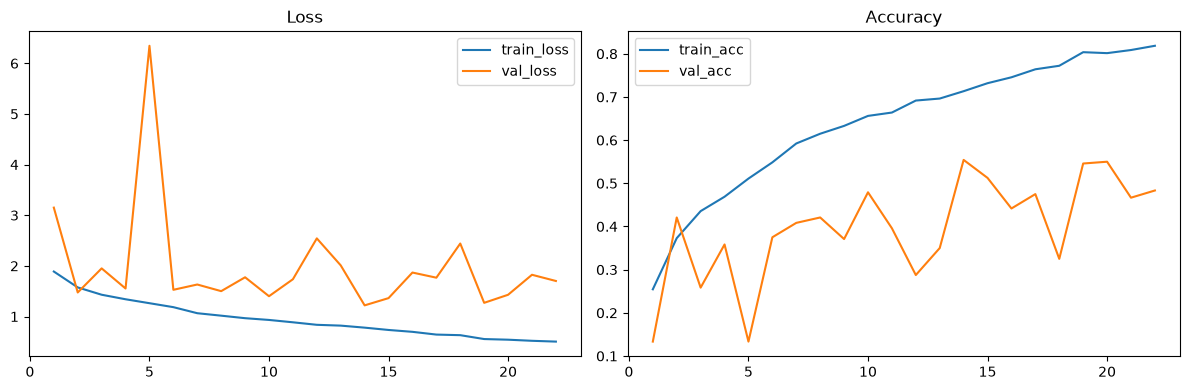

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="train_acc")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
axes[1].set_title("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

4. Run Predictions on Test Set

In [6]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for inputs, labels in loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

y_pred, y_true = get_predictions(model, test_loader, device)
print(f"Predicted {len(y_pred)} samples.")

Predicted 300 samples.


5. Classification Report + Confusion Matrix

In [7]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       angry       0.45      0.57      0.51        40
        calm       0.67      0.55      0.60        40
     disgust       0.49      0.80      0.61        40
     fearful       0.63      0.55      0.59        40
       happy       0.41      0.17      0.25        40
     neutral       0.28      0.25      0.26        20
         sad       0.23      0.12      0.16        40
   surprised       0.58      0.85      0.69        40

    accuracy                           0.50       300
   macro avg       0.47      0.48      0.46       300
weighted avg       0.48      0.50      0.47       300



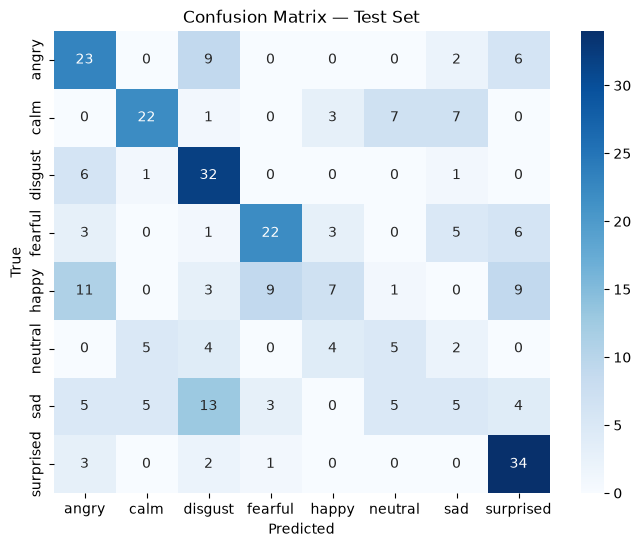

In [8]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.show()

In [9]:
confused_pairs = Counter()
for t, p in zip(y_true, y_pred):
    if t != p:
        confused_pairs[(class_names[t], class_names[p])] += 1

print("--- Top confused emotion pairs (true -> predicted : count) ---")
for (true_label, pred_label), count in confused_pairs.most_common(5):
    print(f"{true_label:>12} -> {pred_label:<12}: {count}")

--- Top confused emotion pairs (true -> predicted : count) ---
         sad -> disgust     : 13
       happy -> angry       : 11
       happy -> surprised   : 9
       angry -> disgust     : 9
       happy -> fearful     : 9


6. Diagnostic — Low-Arousal Collapse Check

In [10]:
def collapse_low_arousal(labels, class_names):
    low_arousal = {"calm", "sad", "neutral"}
    return np.array(["low_arousal" if class_names[l] in low_arousal else class_names[l] for l in labels])

y_true_collapsed = collapse_low_arousal(y_true, class_names)
y_pred_collapsed = collapse_low_arousal(y_pred, class_names)

collapsed_acc = (y_true_collapsed == y_pred_collapsed).mean()
original_acc = (y_true == y_pred).mean()
print(f"Original accuracy: {original_acc:.4f}")
print(f"Accuracy with calm/sad/neutral merged: {collapsed_acc:.4f}")

Original accuracy: 0.5000
Accuracy with calm/sad/neutral merged: 0.6033


7. Diagnostic — Per-Actor Accuracy (Test Set)

In [11]:
sequences, labels, _, flat_df = load_features_and_labels()
unique_actors = flat_df["actor_id"].unique()
_, _, test_actors = get_actor_splits(unique_actors)

test_mask = flat_df["actor_id"].isin(test_actors).values
test_actor_ids = flat_df.loc[test_mask, "actor_id"].values

assert len(test_actor_ids) == len(y_true), "Actor ID array doesn't align with test predictions — check ordering."

per_actor_acc = {}
for actor in sorted(set(test_actor_ids)):
    idx = test_actor_ids == actor
    per_actor_acc[actor] = (y_true[idx] == y_pred[idx]).mean()

for actor, acc in sorted(per_actor_acc.items()):
    print(f"Actor {actor}: acc={acc:.3f}")

Actor 5: acc=0.433
Actor 10: acc=0.517
Actor 14: acc=0.500
Actor 16: acc=0.633
Actor 23: acc=0.417
